In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
pd.read_csv(r"C:\Users\HP\Documents\diabetes_prediction_dataset.csv")

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [4]:
df=pd.read_csv(r"C:\Users\HP\Documents\diabetes_prediction_dataset.csv")

In [5]:
df.info

<bound method DataFrame.info of        gender   age  hypertension  heart_disease smoking_history    bmi  \
0      Female  80.0             0              1           never  25.19   
1      Female  54.0             0              0         No Info  27.32   
2        Male  28.0             0              0           never  27.32   
3      Female  36.0             0              0         current  23.45   
4        Male  76.0             1              1         current  20.14   
...       ...   ...           ...            ...             ...    ...   
99995  Female  80.0             0              0         No Info  27.32   
99996  Female   2.0             0              0         No Info  17.37   
99997    Male  66.0             0              0          former  27.83   
99998  Female  24.0             0              0           never  35.42   
99999  Female  57.0             0              0         current  22.43   

       HbA1c_level  blood_glucose_level  diabetes  
0              

In [6]:
df.shape

(100000, 9)

In [7]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [8]:
filtered_df = df[(df["age"] >= 50) & (df["hypertension"] == 1) & (df["diabetes"] == 1)]

In [9]:
print(filtered_df)

       gender   age  hypertension  heart_disease smoking_history    bmi  \
38       Male  50.0             1              0         current  27.32   
104    Female  80.0             1              0           never  27.32   
242      Male  57.0             1              1     not current  27.77   
254      Male  63.0             1              0            ever  35.06   
350    Female  52.0             1              0           never  50.30   
...       ...   ...           ...            ...             ...    ...   
99739  Female  65.0             1              0           never  35.00   
99792  Female  80.0             1              0           never  21.33   
99867    Male  64.0             1              0          former  33.12   
99935  Female  65.0             1              1           never  33.55   
99962  Female  58.0             1              0           never  38.31   

       HbA1c_level  blood_glucose_level  diabetes  
38             5.7                  260        

In [12]:
below_50_filtered_df=df[(df["age"]<=49) & (df["hypertension"]==1) & (df["diabetes"]==1)]

In [13]:
print(below_50_filtered_df)

       gender   age  hypertension  heart_disease smoking_history    bmi  \
464      Male  48.0             1              0         current  36.12   
531    Female  49.0             1              0     not current  36.93   
626      Male  43.0             1              0     not current  40.86   
727    Female  38.0             1              0     not current  27.32   
751    Female  28.0             1              0           never  20.09   
...       ...   ...           ...            ...             ...    ...   
98175    Male  48.0             1              0          former  28.35   
98312  Female  33.0             1              0         No Info  28.44   
98942  Female  44.0             1              0         No Info  27.32   
99582    Male  35.0             1              0         current  34.29   
99845  Female  43.0             1              0           never  34.21   

       HbA1c_level  blood_glucose_level  diabetes  
464            6.8                  140        

In [15]:
#Analyze the distribution of categorical columns
categorical_cols = ["gender", "hypertension", "heart_disease", "smoking_history", "diabetes"]

for col in categorical_cols:
    print(f"Distribution of {col}:")
    print(df[col].value_counts())
    print()


Distribution of gender:
gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64

Distribution of hypertension:
hypertension
0    92515
1     7485
Name: count, dtype: int64

Distribution of heart_disease:
heart_disease
0    96058
1     3942
Name: count, dtype: int64

Distribution of smoking_history:
smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64

Distribution of diabetes:
diabetes
0    91500
1     8500
Name: count, dtype: int64



In [16]:
# Analyze the column by how many females smoke, have diabetes, hypertension, etc.
female_df = df[df["gender"] == "Female"]


In [17]:
print("Female Smoking History:")
print(female_df["smoking_history"].value_counts())


Female Smoking History:
smoking_history
never          22869
No Info        19700
current         5058
former          4774
not current     3913
ever            2238
Name: count, dtype: int64


This tells us that among females, 22,869 have never smoked, 5,058 are current smokers,4,774 are former smokers, and 19,700 have no information on smoking history.


In [18]:
print("\nFemale Diabetes Status:")
print(female_df["diabetes"].value_counts())



Female Diabetes Status:
diabetes
0    54091
1     4461
Name: count, dtype: int64


This tells us that among females, 4,461 have Diabetes while 54,092 do not have diabetes.

In [19]:
print("\nFemale Hypertension Status:")
print(female_df["hypertension"].value_counts())



Female Hypertension Status:
hypertension
0    54355
1     4197
Name: count, dtype: int64


In [20]:
print("\nFemale Heart Disease Status:")
print(female_df["heart_disease"].value_counts())


Female Heart Disease Status:
heart_disease
0    56990
1     1562
Name: count, dtype: int64


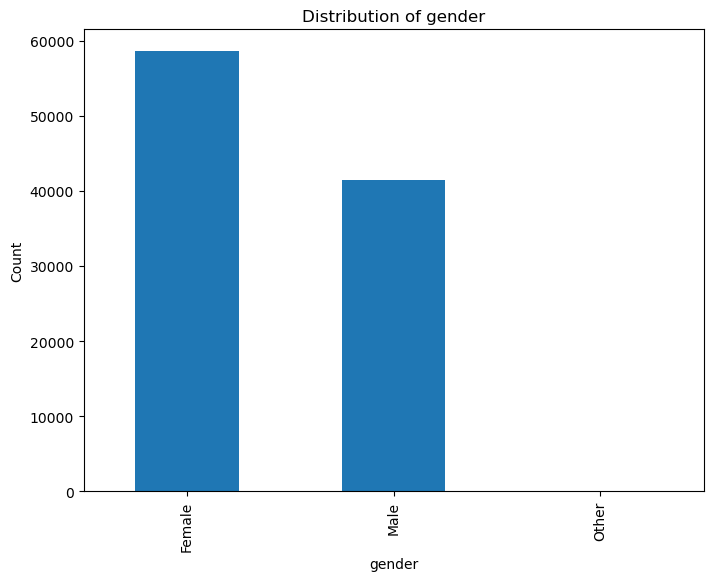

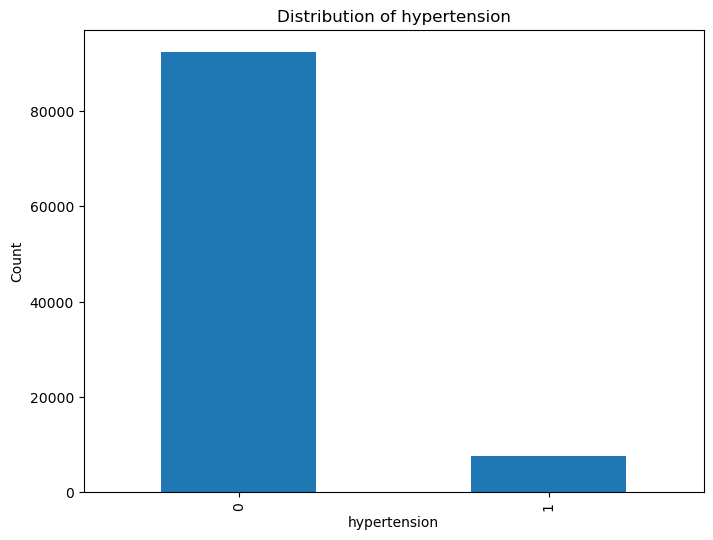

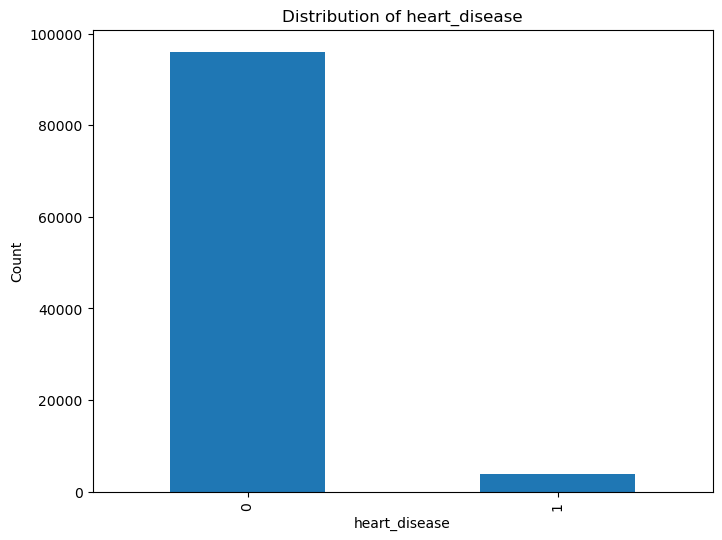

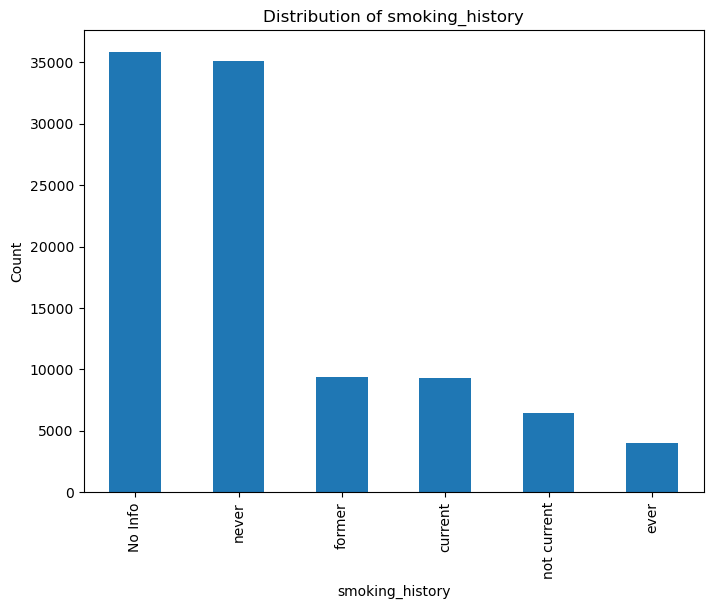

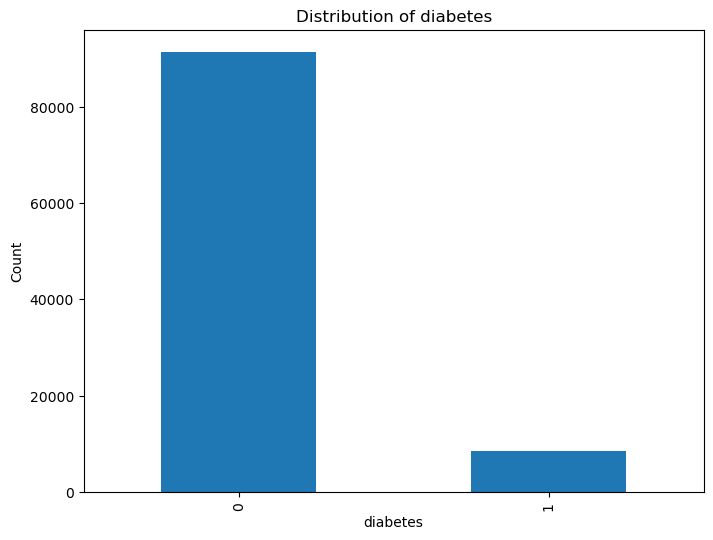

In [21]:
# Bar charts for categorical columns
categorical_cols = ["gender", "hypertension", "heart_disease", "smoking_history", "diabetes"]
for col in categorical_cols:
    plt.figure(figsize=(8, 6))
    df[col].value_counts().plot(kind="bar")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

<Figure size 800x600 with 0 Axes>

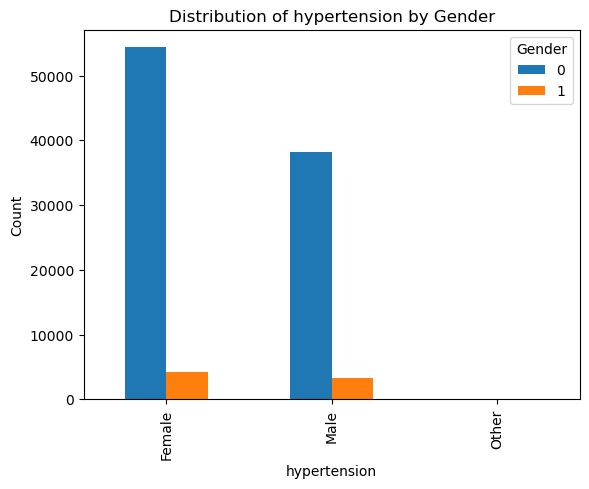

<Figure size 800x600 with 0 Axes>

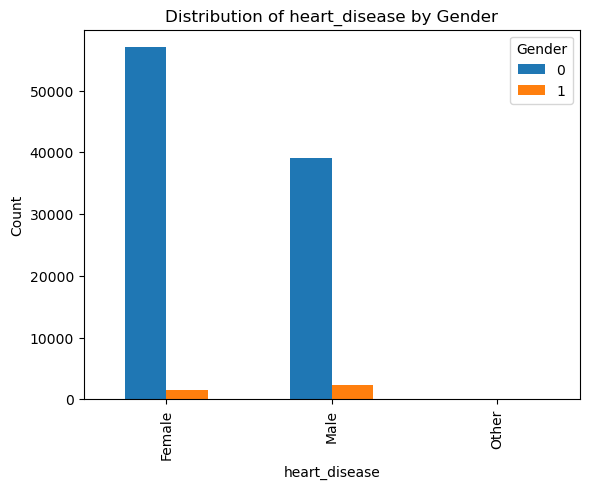

<Figure size 800x600 with 0 Axes>

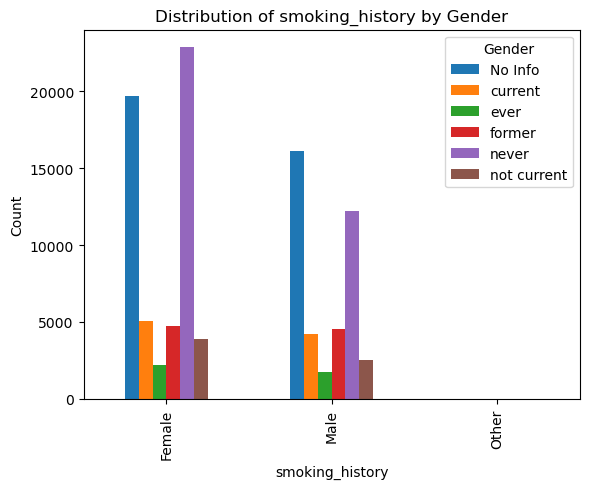

<Figure size 800x600 with 0 Axes>

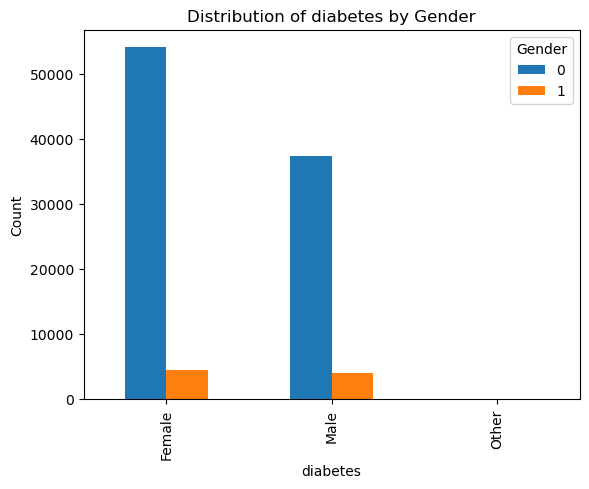

In [22]:
# Bar charts for categorical columns Based on gender
categorical_cols = ["hypertension", "heart_disease", "smoking_history", "diabetes"]

for col in categorical_cols:
    plt.figure(figsize=(8, 6))
    df.groupby("gender")[col].value_counts().unstack().plot(kind="bar")
    plt.title(f"Distribution of {col} by Gender")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend(title="Gender")
    plt.show()

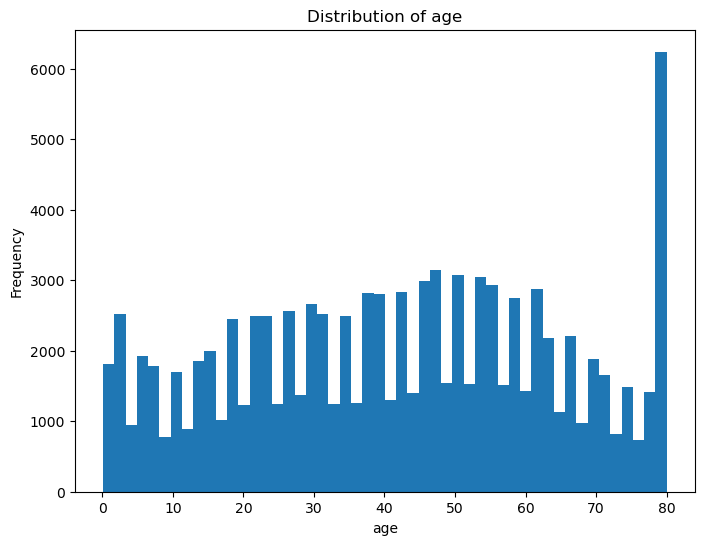

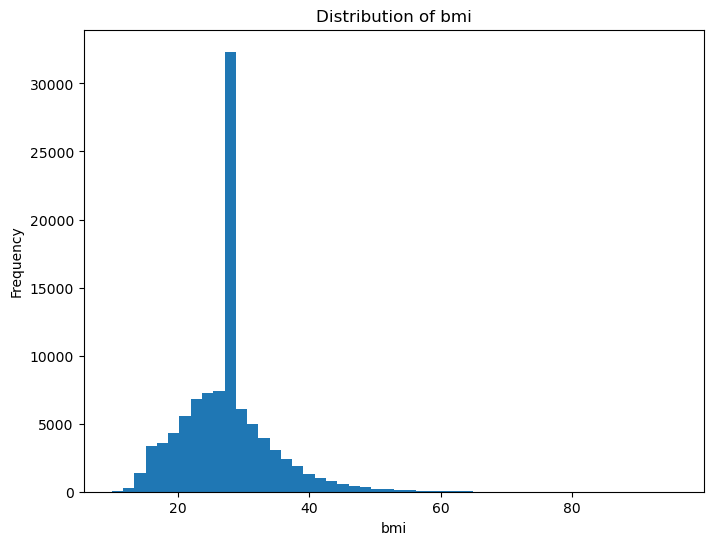

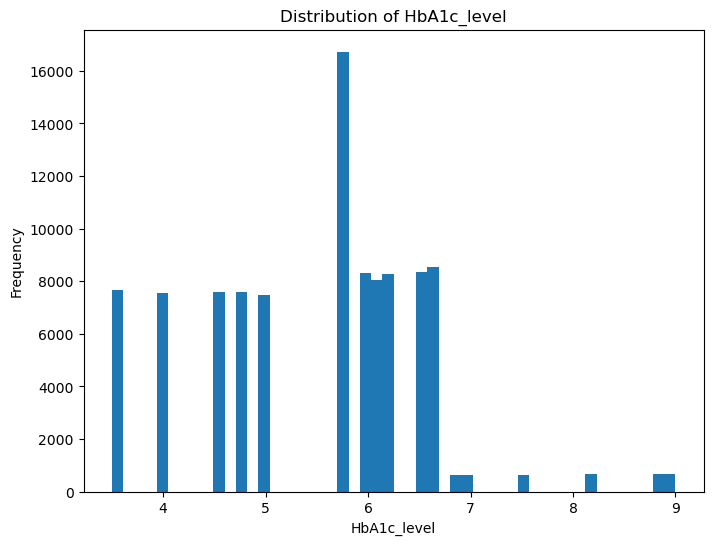

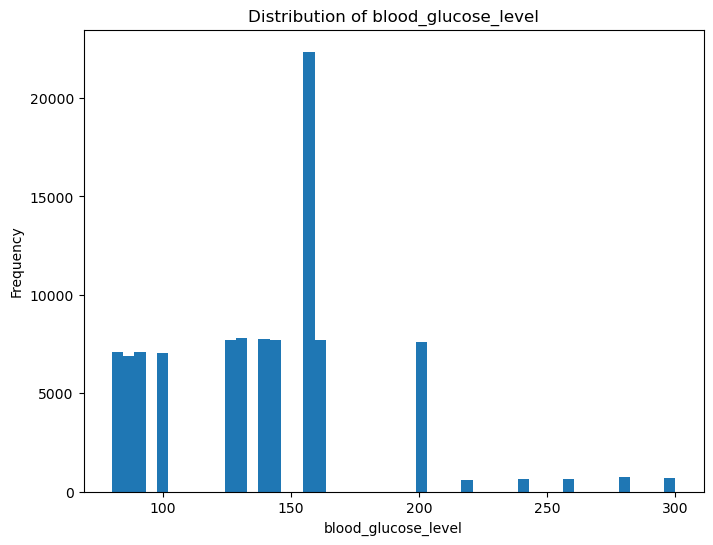

In [23]:
# Histograms for numerical columns
numerical_cols = ["age", "bmi", "HbA1c_level", "blood_glucose_level"]
for col in numerical_cols:
    plt.figure(figsize=(8, 6))
    df[col].plot.hist(bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

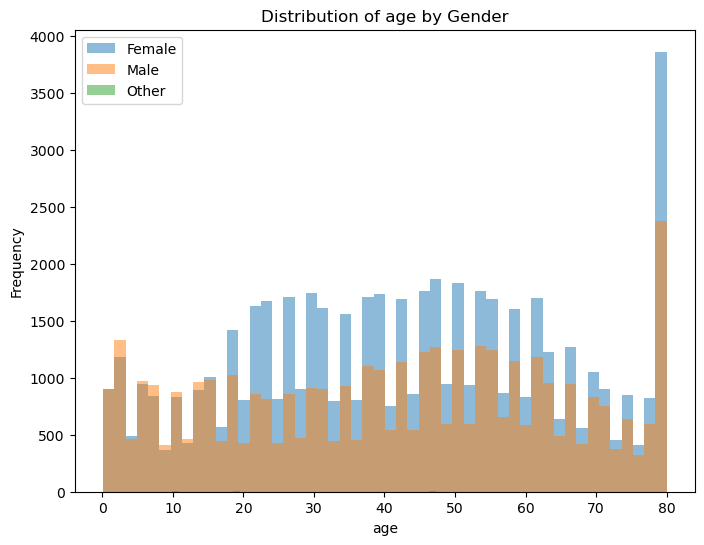

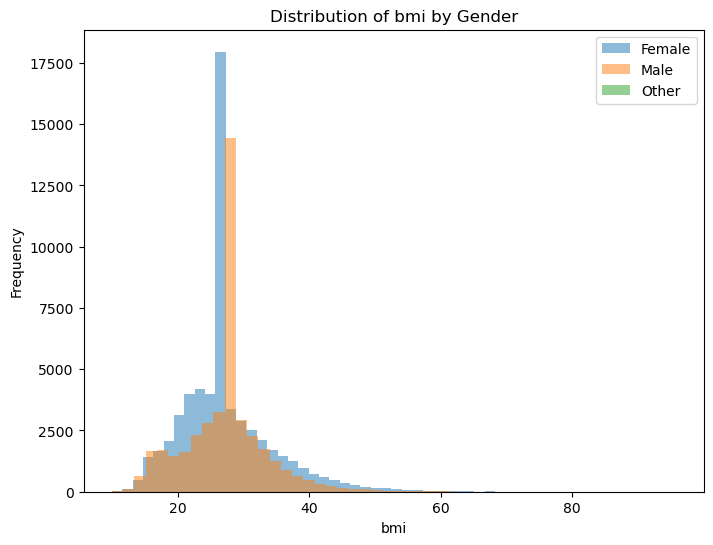

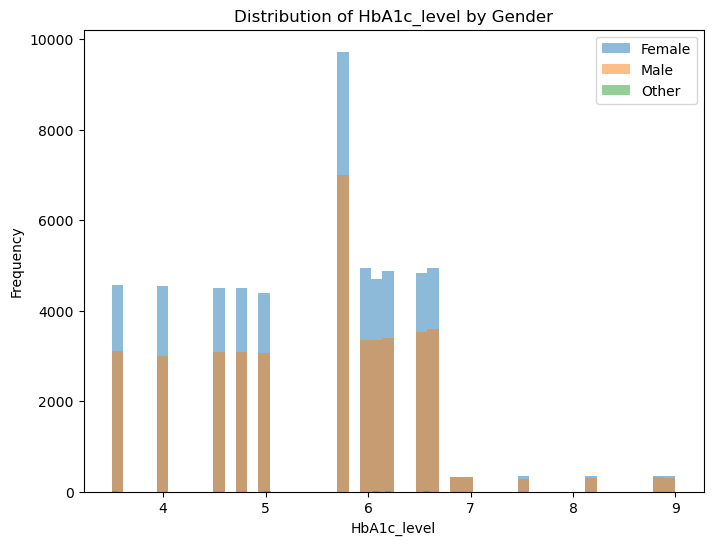

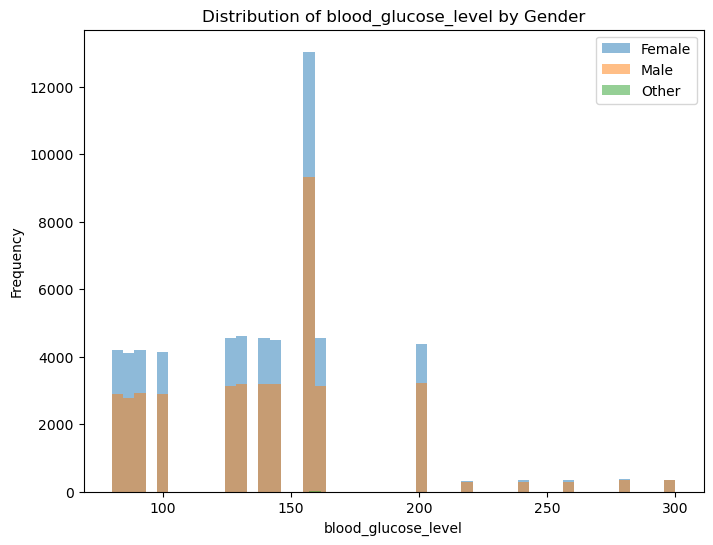

In [24]:
# Histograms for numerical columns by gender
numerical_cols = ["age", "bmi", "HbA1c_level", "blood_glucose_level"]

for col in numerical_cols:
    plt.figure(figsize=(8, 6))
    for gender in df["gender"].unique():
        df_gender = df[df["gender"] == gender]
        plt.hist(df_gender[col], bins=50, alpha=0.5, label=gender)
    plt.title(f"Distribution of {col} by Gender")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

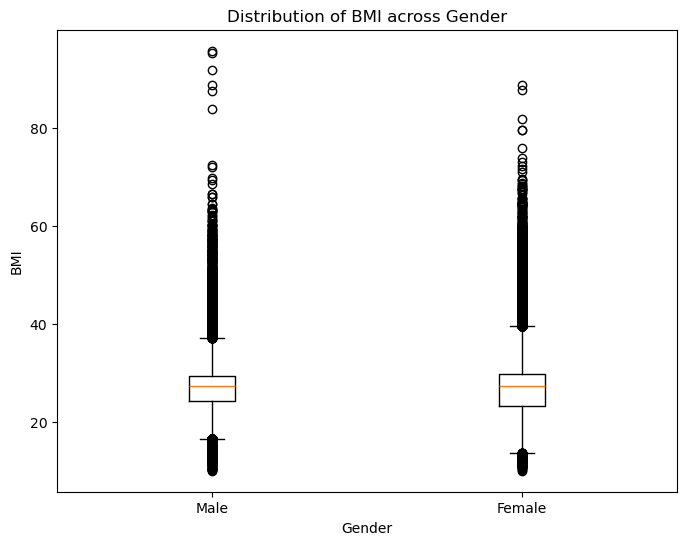

In [25]:
# Box plots for distribution of numerical columns across categories
plt.figure(figsize=(8, 6))
plt.boxplot([df.loc[df["gender"] == "Male", "bmi"], df.loc[df["gender"] == "Female", "bmi"]], labels=["Male", "Female"])
plt.title("Distribution of BMI across Gender")
plt.xlabel("Gender")
plt.ylabel("BMI")
plt.show()

In [26]:
# Calculate correlation matrix
corr_matrix = df[numerical_cols].corr()



In [27]:
# Print correlation matrix
print(corr_matrix)

                          age       bmi  HbA1c_level  blood_glucose_level
age                  1.000000  0.337396     0.101354             0.110672
bmi                  0.337396  1.000000     0.082997             0.091261
HbA1c_level          0.101354  0.082997     1.000000             0.166733
blood_glucose_level  0.110672  0.091261     0.166733             1.000000


The numbers in the table range from -1 to 1. Here's what they mean:

- 1: Perfect positive correlation (when one variable increases, the other increases too)
- -1: Perfect negative correlation (when one variable increases, the other decreases)
- 0: No correlation (the variables don't seem to be related)
                     
- Age vs. BMI: The correlation is 0.337396, which means there's a moderate positive correlation. As people get older, their BMI tends to increase.
- Age vs. HbA1c_level: The correlation is 0.101354, which means there's a weak positive correlation. As people get older, their HbA1c levels might increase slightly.
- Age vs. Blood Glucose Level: The correlation is 0.110672, which means there's a weak positive correlation. As people get older, their blood glucose levels might increase slightly.

The table shows how different health metrics are related to each other. For example, as people get older, their BMI tends to increase. There's also a weak connection between age and blood glucose levels. This information can help us understand how different health factors are connected

In [30]:
import seaborn as sns

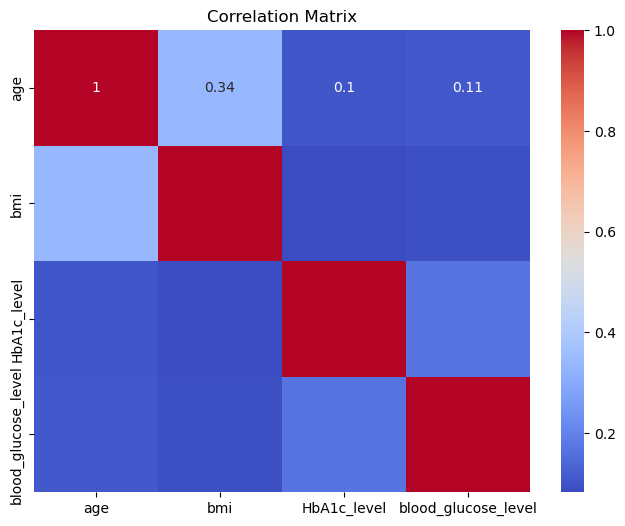

In [31]:
# Visualize correlation matrix using heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


MACHINE LEARNING

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [33]:
# Define the target variable (diabetes)
target = "diabetes"


In [34]:
# Define the feature variables (all columns except diabetes)
features = [col for col in df.columns if col != target]


In [35]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df[features], df[target], test_size=0.2, random_state=42)


In [38]:
from sklearn.preprocessing import LabelEncoder

In [43]:
encoder = LabelEncoder()
X_train['Gender'] = encoder.fit_transform(X_train['gender'])  # Convert 'Male' -> 0, 'Female' -> 1
X_test['Gender'] = encoder.transform(X_test['gender'])  # Apply the same transformation to test set

In [45]:
X_train = X_train.drop('gender', axis=1)
X_test = X_test.drop('gender', axis=1)


In [49]:
from sklearn.preprocessing import LabelEncoder

# Create a LabelEncoder object
le = LabelEncoder()

# Apply the LabelEncoder to the categorical columns
for col in X_train.columns:
    if X_train[col].dtype == 'object':
        X_train[col] = le.fit_transform(X_train[col])
        X_test[col] = le.transform(X_test[col])

In [50]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [51]:
# Make predictions on the testing set
y_pred = model.predict(X_test)

In [52]:
# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.3f}")


Accuracy: 0.970


In [53]:
print("Classification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18292
           1       0.95      0.69      0.80      1708

    accuracy                           0.97     20000
   macro avg       0.96      0.84      0.89     20000
weighted avg       0.97      0.97      0.97     20000



In [54]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[18224    68]
 [  530  1178]]
